<a href="https://colab.research.google.com/github/S-Rawat14/Protein_ligand_complex-visualization-/blob/main/Str_analysis_biotite.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import sys

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    !uv pip install biotite rdkit numpy

Using Python 3.12.12 environment at: /usr
Resolved 14 packages in 310ms
Prepared 3 packages in 1.65s
Installed 3 packages in 57ms
 + biotite==1.6.0
 + biotraj==1.2.2
 + rdkit==2025.9.5


In [ ]:
import biotite.structure.io.pdbx as pdbx  # read and write PDB and CIF files
import biotite.database.rcsb as rcsb      # download data from the RCSB PDB
import biotite.structure.info as info     # get information on residues, etc
from biotite.interface import rdkit       # interface with the RDKit
import biotite.sequence as seq            # sequence information
import biotite.structure as struc         # structure information
import biotite.sequence.io.fasta as fasta # FASTA sequence data
import biotite.sequence.align as align    # sequence alignment

from rdkit import Chem                    # chemical structure and data processing
from rdkit.Chem import rdDepictor         # drawing chemical structures
import numpy as np                        # array and matrix manipulation

In [ ]:
pdb_id = '2l86'
file_path = rcsb.fetch(pdb_id, 'cif', target_path='.')

In [ ]:
pdbx_file = pdbx.CIFFile.read(file_path)
atom_array = pdbx.get_structure(pdbx_file, model=1, include_bonds=True)


In [ ]:
atom_array[0]

Atom(np.array([ 2.519, -8.947,  4.082], dtype=float32), chain_id="A", res_id=1, ins_code="", res_name="LYS", hetero=False, atom_name="N", element="N")

Getting Residue information

In [ ]:
names_2l86 = np.unique(atom_array.res_name)
names_2l86

array(['ALA', 'ARG', 'ASN', 'CYS', 'GLN', 'GLY', 'HIS', 'ILE', 'LEU',
       'LYS', 'NH2', 'PHE', 'SER', 'THR', 'TYR', 'VAL'], dtype='<U5')

 Biotite’s sequence module to identify residues that are not standard amino acids (e.g., ligands, modified residues).

Create a ProteinSequence object

Get its alphabet (1-letter amino acid codes)

Convert those 1-letter codes to 3-letter residue names

Compare against residues present in your structure

In [ ]:
prot_seq = seq.ProteinSequence()
aa_alphabet = prot_seq.get_alphabet()
aa_names = [prot_seq.convert_letter_1to3(x) for x in aa_alphabet]

**For when there is ligand or other molecule (water ,ions , lipids)**

In [ ]:
[x for x in names_2l86 if x not in aa_names]

[np.str_('NH2')]

**Once a ligand has been identified in a structure, the next step is to analyze its chemical properties in a more systematic way.

Using structural bioinformatics tools, one can retrieve standardized information about a ligand based on its residue identifier — including its canonical chemical definition and connectivity. This allows verification of the ligand’s identity beyond just atomic coordinates.

After obtaining the ligand as a structural object (e.g., an `AtomArray`), it can be converted into a cheminformatics-compatible representation such as an RDKit `Mol` object. This transformation bridges structural biology and chemical informatics.

With the ligand represented as a molecular object, it becomes possible to:

* Compute physicochemical descriptors
* Generate molecular fingerprints
* Perform substructure searches
* Optimize or manipulate conformations
* Prepare the compound for docking or virtual screening

In essence, the workflow moves from structural identification to chemically meaningful representation, enabling deeper computational analysis and drug design applications.
** **bold text**

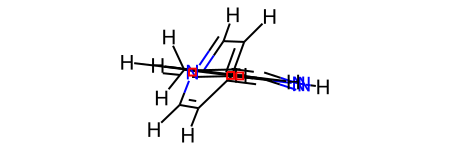

In [ ]:
res_LIG = info.residue("LIG")
ref_mol_LIG = rdkit.to_mol(res_LIG)
ref_mol_LIG

**The canonical residue has 3D coordinates and explicit hydrogens, so it's difficult to understand. We can use the RDKit to calculate 2D coordinates and remove the explicit hydrogens.**



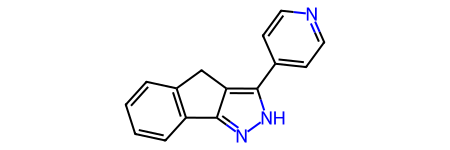

In [ ]:
rdDepictor.SetPreferCoordGen(True)
ref_mol_LIG = Chem.RemoveHs(ref_mol_LIG)
rdDepictor.Compute2DCoords(ref_mol_LIG)
ref_mol_LIG

**### Extracting a Ligand From a Protein Structure

In protein–ligand complexes, the ligand can be isolated for further analysis by selecting its atoms based on structural annotations such as residue name and chain ID.

This is typically done by creating Boolean masks that filter atoms matching specific criteria (e.g., a given residue and chain). These masks can be combined using logical operators to refine the selection.

Applying the combined mask to the structure yields a new object containing only the ligand atoms, ready for downstream analysis.
**

In [ ]:
mask_LIG = (atom_array.res_name == 'LIG') & (atom_array.chain_id == 'A')
LIG_atom_array = atom_array[mask_LIG]

**Converting atom_array into a RDkit molecule**

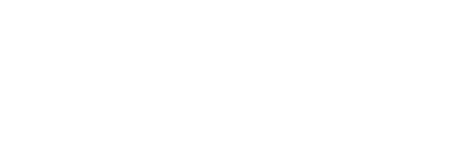

In [ ]:
pdb_mol_LIG = rdkit.to_mol(LIG_atom_array)
pdb_mol_LIG

Comparing the canonical structure for the LIG and  the structure in pdb (cognate ligand) with the , initially by using SMILES and then InChI key

In [ ]:
print(Chem.MolToSmiles(ref_mol_LIG),Chem.MolToSmiles(pdb_mol_LIG))
Chem.MolToSmiles(ref_mol_LIG) == Chem.MolToSmiles(pdb_mol_LIG)

c1ccc2c(c1)Cc1c-2n[nH]c1-c1ccncc1 


False

This another good reason to not use SMILES to determine whether two structures are equivalent. The InChI key is much better choice, because InChI normalizes tautomeric forms. Notice that the InChI keys for the two molecules are the same.

In [ ]:
print(Chem.MolToInchiKey(ref_mol_LIG),Chem.MolToInchiKey(pdb_mol_LIG))
Chem.MolToInchiKey(ref_mol_LIG) == Chem.MolToInchiKey(pdb_mol_LIG)

NHOACLCXCKJMAK-UHFFFAOYSA-N 


[15:14:58] Invalid InChI prefix in generating InChI Key
[15:14:58] Invalid InChI prefix in generating InChI Key


False

Biotite also has a range of methods for dealing with protein sequences. In the cells below we'll see how we get a sequence from a structure or from the PDB. We will extract the sequence of the protein from the 2l8k structure. Next we will get the sequence of protein from the PDB and perform a sequence alignment on the two.




In [ ]:
chain_A_mask = atom_array.chain_id == "A"
protein_mask = struc.filter_amino_acids(atom_array)
protein = atom_array[protein_mask & chain_A_mask]
sequences = struc.to_sequence(protein)
seq_2l8k_A = "".join(sequences[0][0])
seq_2l8k_A

'KCNTATCATQRLANFLVHSSNNFGAILSSTNVGSNTY'

Getting a Protein Sequence From the PDB
In the cell below, we use [biotite.database.rcsb] to get the sequence for a protein structure. Note that we could have also obtained a sequence from NCBI Entrez using biotite.database.entrez. Biotite also has interfaces to PubChem, UniProt and the AlphaFold Database

In [ ]:
fasta_path = rcsb.fetch("2KB8", "fasta")
fasta_file = fasta.FastaFile.read(fasta_path)
for header, sequence in fasta_file.items():
    seq_2KB8 = sequence
    break
seq_2KB8

'KCNTATCATQRLANFLVHSSNNFGAILSSTNVGSNTY'

**Aligning Sequences
With the two sequences in hand, let's align them and determine their sequence identity.**

In [ ]:
alpha_seq = seq.ProteinSequence(seq_2l8k_A)
gamma_seq = seq.ProteinSequence(seq_2KB8)
matrix = align.SubstitutionMatrix.std_protein_matrix()
alignments = align.align_optimal(alpha_seq, gamma_seq, matrix)

In [ ]:
best_alignment = alignments[0]

# Calculate Sequence Identity
# This returns a float between 0.0 and 1.0
identity = align.get_sequence_identity(best_alignment)

# Output results
print(f"Sequence Identity: {identity:.2%}") # Formatted as percentage
print("\nAlignment:")
print(best_alignment)

Sequence Identity: 100.00%

Alignment:
KCNTATCATQRLANFLVHSSNNFGAILSSTNVGSNTY
KCNTATCATQRLANFLVHSSNNFGAILSSTNVGSNTY
